## New York City TLC Taxi Operations & Revenue Analysis

#### Problem Statement : Passenger spending behavior, including fare payments and tipping patterns, directly impacts taxi company profitability. Understanding how factors such as trip distance, location, time of day, and payment method influence customer behavior can help optimize pricing strategies and improve driver earnings. This study analyzes customer transaction patterns to generate actionable business insights

### KPQ:
1) What percentage of customers pay by card versus cash?
2) What are the busiest pickup & Dropoff zones?
3) What percentage of revenue comes from digital payments?
4) How much revenue is generated in rush hours?
5) Which day of week have most revenue
6) Which routes are most frequently traveled?


In [179]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt
import calendar

In [151]:
# Lets Load Dataset
try:
    data = pd.read_csv('data/2017_Yellow_Taxi_Trip_Data.csv')
    location = pd.read_csv('data/taxi_zone_lookup.csv')
    print("data successfully imported")
except FileNotFoundError as e:
    print(f'following error is displayed {e}')

data successfully imported


In [152]:
data.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [153]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

In [154]:
data.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


In [155]:
#Lets check for the duplicate values

data.duplicated().sum()

0

Data don't have any null values and duplicate values. However from descriptive stats we can see data have some unwanted negative values and different datatype than required we will look for them and will try to find appropriate solution for them.

In [156]:
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data.dtypes

Unnamed: 0                        int64
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
dtype: object

In [ ]:
def negative_value_imputer(column_name):
    for col in column_name:
        data.loc[data[col]<0,col]=0

In [ ]:
negative_value_imputer(['fare_amount' ,'extra', 'total_amount'])

In [159]:
data.describe()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699,22699,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,2017-06-29 07:32:48.973126656,2017-06-29 07:49:49.799726848,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.033832,0.333517,0.497445,1.835781,0.312542,0.299551,16.318419
min,1.212700e+04,1.000000,2017-01-01 00:08:25,2017-01-01 00:17:20,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-0.500000,0.000000,0.000000,-0.300000,0.000000
25%,2.852056e+07,1.000000,2017-03-30 03:09:38.500000,2017-03-30 03:11:20.500000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,2017-06-23 12:35:57,2017-06-23 12:55:11,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2017-10-02 10:34:34,2017-10-02 10:53:47,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,2017-12-31 23:45:30,2017-12-31 23:49:24,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000
std,3.274493e+07,0.496838,NaN,NaN,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.212462,0.462744,0.039465,2.800626,1.399212,0.015673,16.069060


1) What percentage of customers pay by card versus cash?

In [160]:
data['payment_type'].value_counts(normalize=True)*100

payment_type
1    67.249659
2    32.014626
3     0.533063
4     0.202652
Name: proportion, dtype: float64

from MetaData file provided we can say ~67% of transaction is by credit card 32% by CASH. People prefered payment type as Credit card over any other method

2) What are the busiest pickup & Dropoff zones?

In our main dataset we only have drop-off ID and pickup ID not actual location names but we do have another CSV file wwith contains recoeds of location withrespective ID we will merge those data so that we can find busiest loation for dropoff and pickup

In [161]:
data1 = data.copy()
data1 = data1.merge(location,left_on='PULocationID',right_on='LocationID',how='inner')
data1.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,LocationID,Borough,Zone,service_zone
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.5,2.76,0.0,0.3,16.56,100,Manhattan,Garment District,Yellow Zone
1,1361166,1,2017-01-05 14:56:32,2017-01-05 15:24:31,2,2.60,1,N,100,237,...,0.0,0.5,0.00,0.0,0.3,18.30,100,Manhattan,Garment District,Yellow Zone
2,58371316,2,2017-07-09 02:27:01,2017-07-09 02:35:16,1,0.79,1,N,100,164,...,0.5,0.5,0.00,0.0,0.3,8.30,100,Manhattan,Garment District,Yellow Zone
3,32275680,1,2017-04-20 07:13:18,2017-04-20 07:29:07,1,3.30,1,N,100,236,...,0.0,0.5,2.85,0.0,0.3,17.15,100,Manhattan,Garment District,Yellow Zone
4,1731352,2,2017-01-20 19:57:42,2017-01-20 20:05:12,1,0.66,1,N,100,186,...,0.5,0.5,1.00,0.0,0.3,8.80,100,Manhattan,Garment District,Yellow Zone


In [162]:
# Converting Location ID to string so easier for Group by and aggregate function
data1['PULocationID'] = data1['PULocationID'].astype(str)

In [163]:
result = data1.groupby('PULocationID').agg(Total_count=('PULocationID','count'),
                                                        City =('Borough','first'),
                                                        Zone = ('Zone','first'),
                                                        Revenue=('total_amount','sum'))
top_pickup_location = result.sort_values(by='Total_count',ascending=False).head()

top_pickup_location

,Total_count,City,Zone,Revenue
PULocationID,,,,
237,890,Manhattan,Upper East Side South,10995.89
161,861,Manhattan,Midtown Center,12757.56
186,792,Manhattan,Penn Station/Madison Sq West,11688.95
236,785,Manhattan,Upper East Side North,9599.78
162,779,Manhattan,Midtown East,11400.89


We get Top 5 Busiest location with most number of pickup location with revenue. Surprisingly all 5 location are from Manhattan

In [164]:
data2 = data.copy()
data2 = data2.merge(location,left_on='DOLocationID',right_on='LocationID',how='inner')
data2.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,LocationID,Borough,Zone,service_zone
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.5,2.76,0.0,0.3,16.56,231,Manhattan,TriBeCa/Civic Center,Yellow Zone
1,47444401,2,2017-06-02 06:41:39,2017-06-02 06:57:47,1,5.93,1,N,239,231,...,0.0,0.5,3.00,0.0,0.3,22.80,231,Manhattan,TriBeCa/Civic Center,Yellow Zone
2,3377025,2,2017-01-13 02:37:24,2017-01-13 03:17:34,4,8.69,1,N,246,231,...,0.5,0.5,6.56,0.0,0.3,39.36,231,Manhattan,TriBeCa/Civic Center,Yellow Zone
3,36762559,2,2017-05-01 09:42:27,2017-05-01 09:47:29,1,0.78,1,N,13,231,...,0.0,0.5,1.00,0.0,0.3,6.80,231,Manhattan,TriBeCa/Civic Center,Yellow Zone
4,11538055,2,2017-02-07 08:56:08,2017-02-07 09:07:32,1,0.72,1,N,211,231,...,0.0,0.5,0.00,0.0,0.3,8.80,231,Manhattan,TriBeCa/Civic Center,Yellow Zone


In [165]:
data2['DOLocationID'] = data2['DOLocationID'].astype(str)

In [166]:
#Lets find busiest Drop-off location
result1 = data2.groupby('DOLocationID').agg(Total_count=('DOLocationID','count'),
                                                        City =('Borough','first'),
                                                        Zone = ('Zone','first'),
                                                        Revenue=('total_amount','sum'))
top_dropoff_location = result1.sort_values(by='Total_count',ascending=False).head()

top_dropoff_location

,Total_count,City,Zone,Revenue
DOLocationID,,,,
161,858,Manhattan,Midtown Center,12450.26
236,802,Manhattan,Upper East Side North,9532.62
230,761,Manhattan,Times Sq/Theatre District,12764.50
237,759,Manhattan,Upper East Side South,8544.58
170,699,Manhattan,Murray Hill,9123.40


We have top Drop-off location and all of them are from Manhattan as well

3) What percentage of revenue comes from digital payments?

We basically Two important payment mode Credit card and Cash( There are another 3 method but they were not fall in main payment method and thier contribution is also negligible ) 

In [234]:
data.groupby('payment_type')['fare_amount'].mean()

payment_type
1    13.429748
2    12.213546
3    12.367934
4    12.989130
Name: fare_amount, dtype: float64

In [167]:
credit_payment = data[data['payment_type']==1]

In [168]:
Digital_payment_percentage = (credit_payment['total_amount'].sum()/data['total_amount'].sum())*100
Digital_payment_percentage

72.79317702063425

In [169]:
cash_payment = data[data['payment_type']== 2]


In [170]:
cash_payment_percentage = (cash_payment['total_amount'].sum()/data['total_amount'].sum())*100
cash_payment_percentage

26.57514762151605

4) How much revenue is generated in rush hours?

In [171]:

# Lets create the hours column 

data['Hour'] = data['tpep_pickup_datetime'].dt.hour
data['day'] = data['tpep_pickup_datetime']. dt.day_name().str.lower()
data.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,Hour,day
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56,8,saturday
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80,14,tuesday
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75,7,friday
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69,13,sunday
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80,23,saturday


Let define rush Hours first from Mon-fri, 06:00-10:00 and in evening 04:00-08:00 We are not going to consider saturday and sunday.

In [172]:
data['rush_hour'] = data['Hour']
data.loc[(data['day']=='saturday')|(data['day']=='sunday'),'rush_hour']=0

In [173]:
def rush_hourizer(hour):
    if 6<=hour['rush_hour']<10:
        val=1
    elif 16<=hour['rush_hour']<20:
        val=1
    else:
        val=0

    return val

In [174]:
data['rush_hour']= data.apply(rush_hourizer,axis=1)

In [175]:
rush_hour_data = data[data['rush_hour']==1]

In [176]:
revenue_Generated_at_rush_hour = rush_hour_data['total_amount'].sum()
revenue_Generated_at_rush_hour

109744.90000000001

In [177]:
rush_hour_percentage = (rush_hour_data['total_amount'].sum()/data['total_amount'].sum())*100
rush_hour_percentage

29.627809633165292

Total revenue generated during rush hour is $109.7K which is 29.62% of total revenue. Its major factor contributing toward revenue. its only 8 Hours total per day from Monday to Friday

5) Which day of week have most revenue

In [183]:
revenue_by_day = data.groupby(['day']).agg(Total_revenue=('total_amount','sum'))
#day_index = list(calendar.day_name)
day_index = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
revenue_day_reindex = revenue_by_day.reindex(day_index,fill_value=0)
revenue_day_reindex

,Total_revenue
day,
monday,49582.47
tuesday,52530.94
wednesday,55317.57
thursday,57190.51
friday,55830.34
saturday,51325.30
sunday,48634.66


In [195]:
revenue_day_reindex=revenue_day_reindex.reset_index(drop=False)


Text(0.5, 1.0, 'Total Revenue per Day of Week')

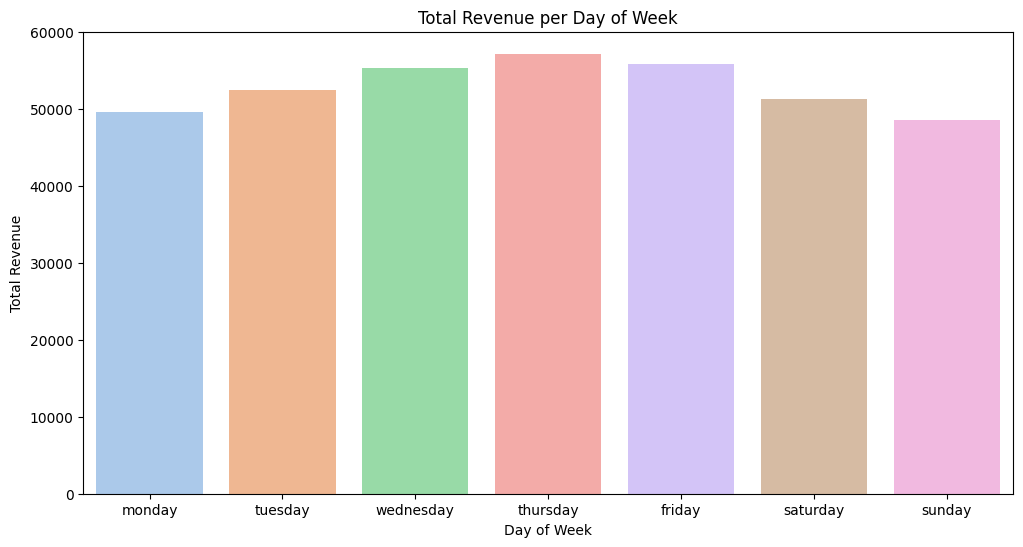

In [202]:
plt.figure(figsize=(12,6))
sns.barplot(x=revenue_day_reindex['day'],y=revenue_day_reindex['Total_revenue'],hue=revenue_day_reindex['day'],palette='pastel',legend=False)
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.title("Total Revenue per Day of Week")

We can see Thursday is having max revenue $57.1K. revenue Shows increasing trend unitl thursay after it decline. Weekend shows least revenue compare to the weekday.

6) Which routes are most frequently traveled?

In [204]:
data['pick_drop'] = data['PULocationID'].astype(str) + ' ' + data['DOLocationID'].astype(str)
data.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,Hour,day,rush_hour,pick_drop
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.5,2.76,0.0,0.3,16.56,8,saturday,0,100 231
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.5,4.00,0.0,0.3,20.80,14,tuesday,0,186 43
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.5,1.45,0.0,0.3,8.75,7,friday,1,262 236
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.5,6.39,0.0,0.3,27.69,13,sunday,0,188 97
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.5,0.5,0.00,0.0,0.3,17.80,23,saturday,0,4 112


In [207]:
data.groupby('pick_drop')['trip_distance'].count().sort_values(ascending=False).head()

pick_drop
264 264    277
237 236    124
236 236    110
236 237    102
237 237     96
Name: trip_distance, dtype: int64

Route 264 which is outside of newyorks have maximum number of trip also 236 is "Manhattan","Upper East Side North" and 237 is "Manhattan","Upper East Side South" this are most popular routes having most number of rides.

In [218]:
#Lets see is there any relation between Fare amount and trip distance

data['duration'] = round((data['tpep_dropoff_datetime']-data['tpep_pickup_datetime'])/np.timedelta64(1,'m'),3)
data.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,Hour,day,rush_hour,pick_drop,duration
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.5,2.76,0.0,0.3,16.56,8,saturday,0,100 231,14.067
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.5,4.00,0.0,0.3,20.80,14,tuesday,0,186 43,26.500
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.5,1.45,0.0,0.3,8.75,7,friday,1,262 236,7.200
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.5,6.39,0.0,0.3,27.69,13,sunday,0,188 97,30.250
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.5,0.00,0.0,0.3,17.80,23,saturday,0,4 112,16.717


In [219]:
data['duration'].describe()

count    22699.000000
mean        17.013776
std         61.996481
min        -16.983000
25%          6.650000
50%         11.183000
75%         18.383000
max       1439.550000
Name: duration, dtype: float64

In [ ]:
negative_value_imputer(['duration'])

In [221]:
data['duration'].describe()

count    22699.000000
mean        17.014524
std         61.996174
min          0.000000
25%          6.650000
50%         11.183000
75%         18.383000
max       1439.550000
Name: duration, dtype: float64

Lets check,is fare amount is have any correlation between trip duration? 

<Axes: xlabel='duration', ylabel='fare_amount'>

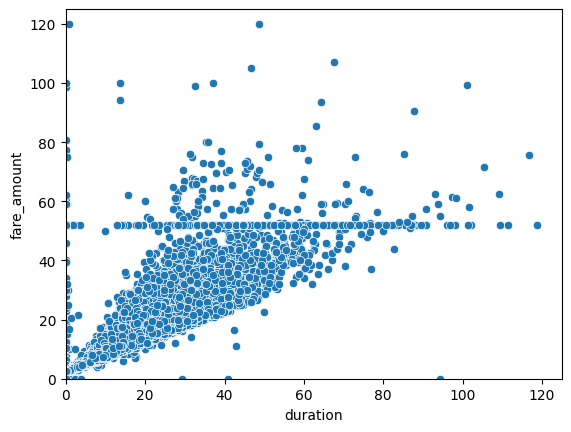

In [233]:
plt.xlim(0,125)
plt.ylim(0,125)
sns.scatterplot(x=data['duration'],y=data['fare_amount'])


Lets plot Revenue By Month

In [243]:
data['month'] = data['tpep_dropoff_datetime'].dt.strftime('%b').str.lower()

In [252]:
month_group = data.groupby(['month'])[['total_amount']].sum()
re_index = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
re_index_month = month_group.reindex(re_index,fill_value=0)
re_index_month.reset_index()
re_index_month

,total_amount
month,
jan,31725.75
feb,28956.99
mar,33091.69
apr,32137.14
may,33818.82
jun,32918.78
jul,26635.28
aug,27770.12
sep,28211.18


Text(0.5, 1.0, 'Total Revenue per Month')

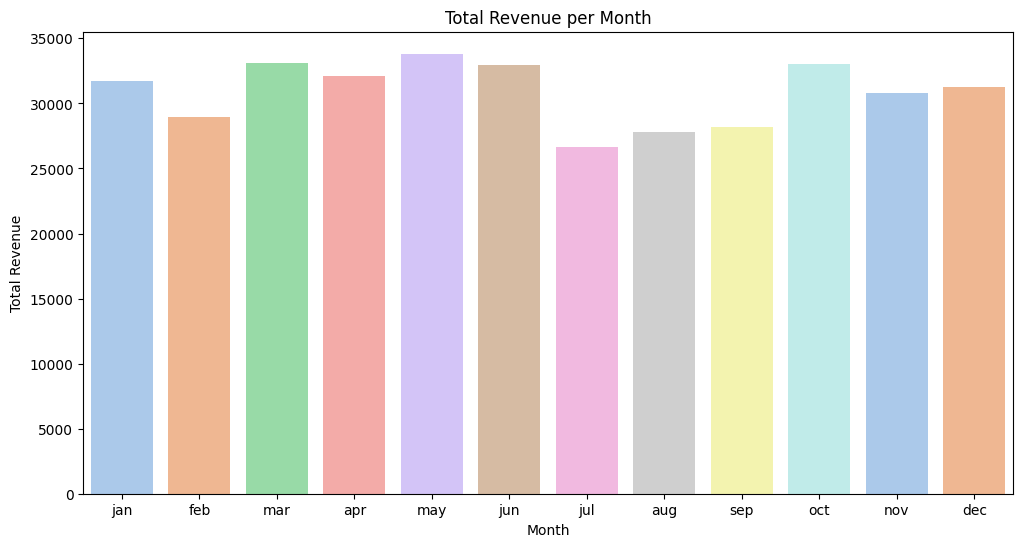

In [255]:
plt.figure(figsize=(12,6))
sns.barplot(data = re_index_month, x='month',y='total_amount',hue='month',palette='pastel',legend=False)
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Total Revenue per Month")

##### plot histogram for trip_duration and trip_distance

<Axes: xlabel='trip_distance', ylabel='Count'>

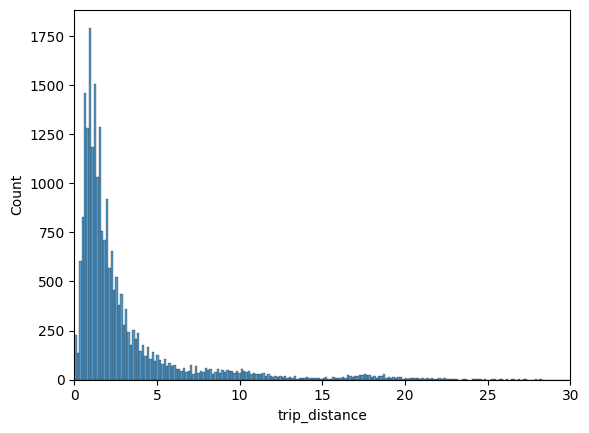

In [263]:
plt.xlim(0,30)
sns.histplot(data=data,x = 'trip_distance')

<Axes: xlabel='duration', ylabel='Count'>

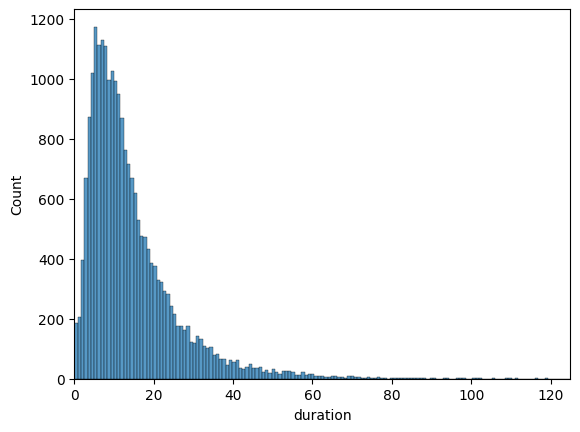

In [260]:
plt.xlim(0,125)
sns.histplot(data=data,x = 'duration')

Lets Plot Corr plot for dataset

In [266]:
column_lst = ['passenger_count','trip_distance','PULocationID','DOLocationID','payment_type','fare_amount','tip_amount','total_amount','Hour','day','rush_hour','duration']
corr_matrix = data[column_lst].corr(numeric_only=True)
corr_matrix

,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,Hour,rush_hour,duration
passenger_count,1.000000,0.016496,-0.005721,0.000332,0.016178,0.010455,-0.009975,0.007595,0.009361,-0.022035,0.016832
trip_distance,0.016496,1.000000,-0.080737,-0.093342,-0.044716,0.757989,0.502242,0.768165,-0.009338,-0.039352,0.153618
PULocationID,-0.005721,-0.080737,1.000000,0.097142,-0.006449,-0.051791,-0.022284,-0.050557,0.031612,0.020344,-0.011072
DOLocationID,0.000332,-0.093342,0.097142,1.000000,-0.011300,-0.064201,-0.034482,-0.062362,0.020512,0.033401,-0.014071
payment_type,0.016178,-0.044716,-0.006449,-0.011300,1.000000,-0.041182,-0.445044,-0.116044,-0.015803,-0.046697,0.018123
fare_amount,0.010455,0.757989,-0.051791,-0.064201,-0.041182,1.000000,0.680087,0.987305,-0.000517,-0.016683,0.137589
tip_amount,-0.009975,0.502242,-0.022284,-0.034482,-0.445044,0.680087,1.000000,0.771944,0.013556,0.009980,0.072609
total_amount,0.007595,0.768165,-0.050557,-0.062362,-0.116044,0.987305,0.771944,1.000000,0.010598,-0.001056,0.133885
Hour,0.009361,-0.009338,0.031612,0.020512,-0.015803,-0.000517,0.013556,0.010598,1.000000,-0.040670,0.012558
rush_hour,-0.022035,-0.039352,0.020344,0.033401,-0.046697,-0.016683,0.009980,-0.001056,-0.040670,1.000000,-0.002722


<Axes: >

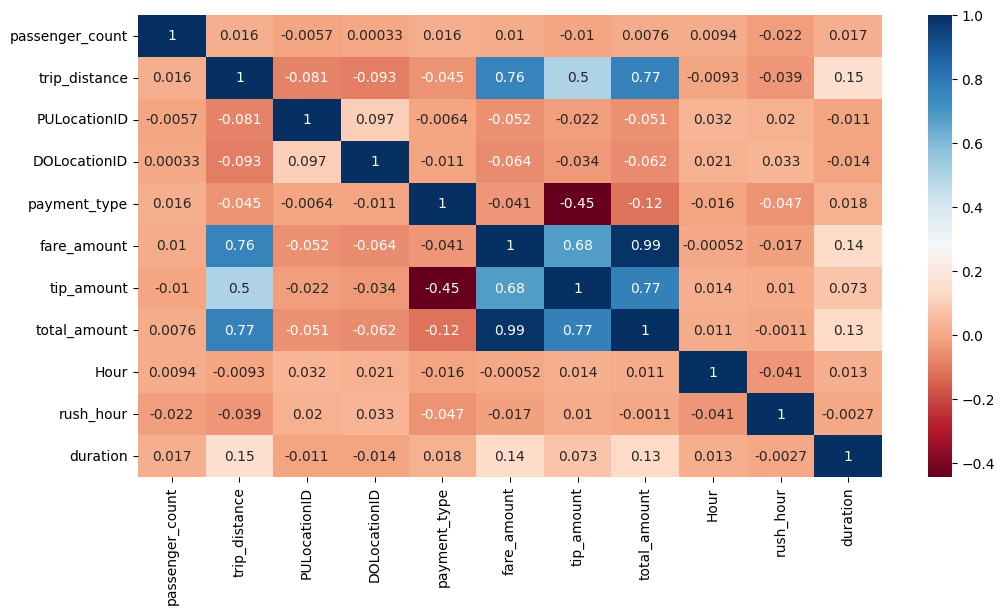

In [269]:
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix,annot=True,cmap='RdBu')

#### Conclusion:

1) Credit card transactions account for approximately 67% of all trips, indicating strong customer preference for digital payments.
2) Manhattan dominates both pickup and dropoff activity, with the busiest zones generating the highest trip volumes and revenue contributions.
3) Rush-hour operations (weekday morning and evening periods) contribute approximately 30% of total revenue, making these periods criticalfor service optimization.